### ANSWER
Learning objectives assessed:

* Load data into notebooks using Pandas
* Determine the components of the data
* Make meaningful visual representations of the data
* Draw conclusions from statistical analysis


### Instructor guide:

The primary goal of this quiz is to assess students' knowledge of loading, filtering (single condition masks), doing a simple statistics calculation using built in numpy or pandas functions (mean, median, standard deviation), creating a simple plot (1 or 2 variables), making observations about that plot and the things they calculated. Detailed structure for your quiz is given below! You should make sure to choose a data file that is in .csv format and has several (4-6 is a good range) columns of data. Students should primarily be using pandas to laod an filter the data and matplotlib to visualize.


* **Question 1 (15 points):** Load the data into a dataframe and describe the columns it contains
* **Question 2 (20 points):** Filter the dataframe based on a single condition (e.g. mask = my_dataframe['my_column']<=1 ) and do a simple calculation (mean or median, maybe standard deviation)
* **Question 3 (40 points):** Combine a calculation with filtering and visualizing (e.g. make several masks very similar to those in part 2, repeat the same calculation form step 2, and then visualize that calculation)
* **Question 4 (15 points):** Ask students to make a claim based on the plot they made

The example below is one possible implementation of this structure, but I can provide additional examples if you aren't sure what to do!

In [1]:
### ANSWER
import pandas as pd
import matplotlib.pyplot as plt

pl_data = pd.read_csv('openipf-2022-10-05-f2033d0e.csv')
pl_data.drop(columns=['Name', 'Sex', 'Event',
       'BirthYearClass', 'Place', 'Dots', 'Wilks', 'Glossbrenner',
       'Goodlift', 'Tested', 'Country', 'State', 'Federation',
       'ParentFederation', 'Date', 'MeetCountry', 'MeetState', 'MeetTown',
       'MeetName','Squat1Kg', 'Squat2Kg', 'Squat3Kg', 'Squat4Kg', 'Bench1Kg', 'Bench2Kg', 'Bench3Kg', 'Bench4Kg', 'Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg',
       'Deadlift4Kg', 'AgeClass', 'Division',
       'WeightClassKg'],inplace=True)
pl_data.head()

FileNotFoundError: [Errno 2] No such file or directory: 'openipf-2022-10-05-f2033d0e.csv'

In [ ]:
### ANSWER
#pl_data.dtypes
pl_data = pl_data[pl_data['Equipment']=='Raw']
#pl_data.dropna(subset=['TotalKg','Age','BodyweightKg'],inplace=True)
#pl_data.keys()
pl_data.dropna(inplace=True)
#pl_data.describe()
pl_data.drop(columns=['Equipment'],inplace=True)

In [ ]:
### ANSWER
plt.hist(pl_data['Age'])
print(pl_data['Age'].mean())
age_mask = pl_data['Age'] % 1 == 0.0
age_pl_data = pl_data[age_mask]
#age_mask
#age_pl_data.describe()
age_pl_data.to_csv('open_pl_for_quiz.csv',index=False)

In [ ]:
### ANSWER
test_mask = age_pl_data['Age']==25
twofive_data = age_pl_data[test_mask]
print(twofive_data['TotalKg'].mean())
plt.hist(twofive_data['TotalKg'])

In [ ]:
###ANSWER
import numpy as np
years = np.arange(20,40,1)
means = []
for year in years:
    mask = age_pl_data['Age']==year
    data = age_pl_data[mask]
    means.append(data['TotalKg'].mean())
    print(data['TotalKg'].mean())
    
plt.plot(years,means)

## <p style="text-align: right;"> &#9989; Put your name here</p>

# CMSE 201: Quiz 3 (Section 006 - Fall 2022)

The goal of this quiz is to give you the opportunity to test out some of the skills that you've developed thus far this semester. In particular, you'll reflect on what you know about writing code using Python and showcase some of your new programming skills.

**Important note about using online resources**: This exam is "open internet". That means that you can look up documentation, google how to accomplish certain Python tasks, etc. Being able to effectively use the internet for computational modeling and data science is a very important skill, so we want to make sure you have the opportunity to exercise that skill. **However, the use of any person-to-person communication software is absolutely not acceptable.**

**Do your own work.** This quiz is designed to give *you* the opportunity to show the instructor what you can do and you should hold yourself accountable for maintaining a high level of academic integrity. Any violation of academic integrity could result in you receiving a zero on the quiz.

---
# Academic integrity statement [10 points]

In the markdown cell below, put your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.


<font size=+3>&#9998;</font> *Put your personal academic integrity statement here.*

---

# Analyzing Athletic Performance in Powerlifting

You have landed your first data science internship at the Center for Obscure Sports. Your first assignment is to explore how overall performance in powerlifting changes with age. Your team lead has given you a datafile called `open_pl_for_quiz.csv` that you are going to explore with `pandas` and other python modules to see what you can learn and share with your team.

#### Background Information on Powerlifting for the Curious
Powerlifting is a strength sport in which lifters compete for the highest total across their squat, bench press, and deadlift. Each competitor gets three attempts at each lift (squat, bench, and deadlift), and the best of the three attempts on each lift are added up to the competitor's "Total." The competitors are divided up into weight classes, and the competitor with the highest total in their weight class wins. If a lifter misses all three attempts for a squat, bench, or deadlift, they are disqualified and do not get a Total. A miss is any attempt that a competitor fails to complete as judged by the referees.

#### &#9989;&nbsp; **Part 1 (15 points):** Examine the data file and describe the columns of data it contains to the best of your knowledge.

In [2]:
# Write any code you need here


In [8]:
### ANSWER ###

import pandas as pd

df = pd.read_csv("open_pl_for_quiz.csv")
df.describe()

,Age,BodyweightKg,Best3SquatKg,Best3BenchKg,Best3DeadliftKg,TotalKg
count,64667.000000,64667.000000,64667.000000,64667.000000,64667.000000,64667.000000
mean,30.388931,82.375181,167.348365,109.325334,195.293407,471.966525
std,12.639905,21.270554,58.967997,42.831573,58.791816,155.724271
min,8.000000,22.680000,11.300000,10.000000,20.400000,72.600000
25%,21.000000,66.280000,120.000000,72.500000,147.500000,344.730000
50%,26.000000,81.000000,165.000000,110.000000,195.500000,475.000000
75%,37.000000,92.900000,210.000000,140.000000,240.000000,587.500000
max,92.000000,240.000000,490.000000,291.500000,417.500000,1112.500000


<font size=+3>&#9998;</font> *Put your answer here.*


### ANSWER ###

Data file contains six columns: Age, bodyweight, Best squat, best bench, best deadlift, and best total.
year, monh, date_of_month, day_of_week, and births. There are 64667 rows, and it contains information about the weight class and lifting performance of powerlifters.

Rubric:
10 points for reading in the file
5 points for describing the contents

#### &#9989;&nbsp; **Part 2 (20 points):** Select all of the data for one lifter age of your choice (e.g., where 'Age' column is equal to 25). Print out the mean (average) of the 'TotalKg' column for all of the lifters of the age you chose. 

In [9]:
# Write any code you need here

In [10]:
### ANSWER ###

df_twofive = df[df["Age"] == 25]
twofive_mean = df_twofive["TotalKg"].mean()
print(twofive_mean)

# Rubric
# 5 points for any masking attempt
# 5 points for a correct mask
# 5 points for calculating mean (partial for any attempt)
# 5 points for printing

511.56729362985294


#### &#9989;&nbsp; **Part 3 (40 points):** Calculate the mean total (from the 'TotalKg' column) for ages ranging from 20 to 40 in steps of 1 year (i.e. you should have ~20 data points in all). Make a plot showing the average total for each age. 


In [11]:
# Write any code you need here

478.8634827586207
489.33221041155616
503.56774426719835
509.5846185397867
513.4234134960518
511.56729362985294
508.58649094567403
512.9262642465173
512.3988669238187
514.4333316195372
509.8131067961164
511.2413982770046
514.3420338983052
510.70660914581543
500.45891866913115
511.7952883675464
484.91436819172117
476.32600487210715
480.48148555708394
468.43702850877185


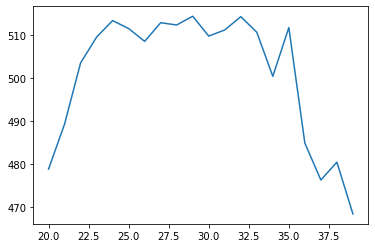

In [13]:
### ANSWER ###

import matplotlib.pyplot as plt
import numpy as np

years = np.arange(20,40,1)
means = []
for year in years:
    mask = df['Age']==year
    data = df[mask]
    means.append(data['TotalKg'].mean())
    print(data['TotalKg'].mean())
    
plt.plot(years,means)

# rubric
# 15 pts for mean (10pts for any attempt), 
# 15 pts for additional years
# 10 pts for correct plot with labels (5pts for any attempt)

#### &#9989;&nbsp; **Part 4 (15 points):** Use the figure you just created to answer the following question: At what age does the average powerlifter's performance (how high total weight lifted is) start to decrease? 

<font size=+3>&#9998;</font> *Put your answer here.*

### ANSWER
Around age 35

Rubric:

15 pts for any reasonable attempt to answer the question
5 pts for any attempt

---

### Congratulations, you're done!

Submit this quiz by uploading it to the course Desire2Learn web page.  Go to the "Quizzes" section, find the submission folder link for Quiz #3, and upload it there.

&#169; Copyright 2021,  Michigan State University Board of Trustees